In [1]:
#-- 기본 설정 + DB 연결 + 데이터 범위 확인

import pandas as pd
import sqlite3
import os
import matplotlib.pyplot as plt

# 현재 작업 경로 확인
print("현재 작업 폴더:", os.getcwd())

# DB 연결
conn = sqlite3.connect("../db/olist.db")

# 주문 데이터 범위 확인
print(pd.read_sql("""
SELECT
    MIN(order_purchase_timestamp) AS first_order,
    MAX(order_purchase_timestamp) AS last_order,
    COUNT(*) AS total_orders
FROM orders;
""", conn))

현재 작업 폴더: /Users/chaeyoung/Documents/GitHub/olist-ecommerce-analysis/notebooks
           first_order           last_order  total_orders
0  2016-09-04 21:15:19  2018-10-17 17:30:18         99441


  order_status  order_count  order_pct
0    delivered        96478      97.02
1      shipped         1107       1.11
2     canceled          625       0.63
3  unavailable          609       0.61
4     invoiced          314       0.32
5   processing          301       0.30
6      created            5       0.01
7     approved            2       0.00


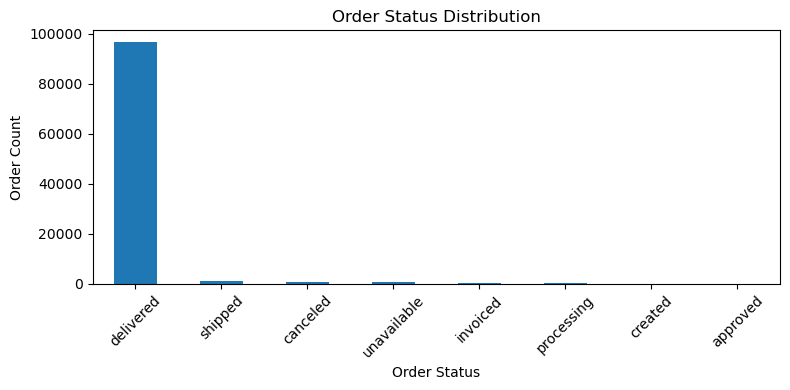

In [2]:
#- 주문 상태 분포 확인

# 주문 상태별 건수 / 비율 확인
order_status = pd.read_sql("""
SELECT
    order_status,
    COUNT(*) AS order_count,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM orders), 2) AS order_pct
FROM orders
GROUP BY order_status
ORDER BY order_count DESC;
""", conn)

print(order_status)

# 시각화
order_status.plot(
    kind="bar",
    x="order_status",
    y="order_count",
    figsize=(8, 4),
    legend=False
)

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Order Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()